In [69]:
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt

In [70]:
iris = load_iris(as_frame=True)
df = iris.frame
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


Text(0, 0.5, 'width')

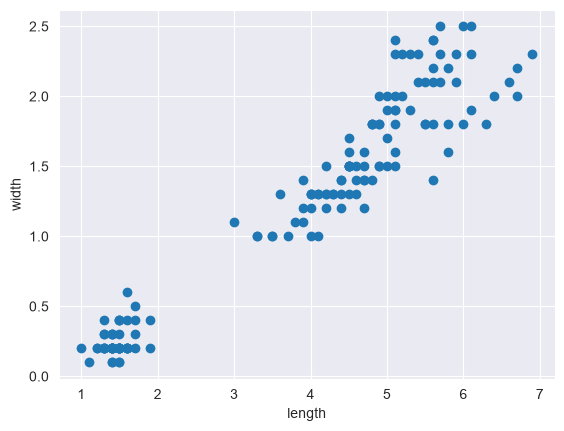

In [71]:
plt.scatter(df["petal length (cm)"], df["petal width (cm)"])
plt.xlabel("length")
plt.ylabel("width")

In [72]:
sse = []
for k in range(1, 10):
    km = KMeans(n_clusters=k)
    km.fit(df[["petal length (cm)","petal width (cm)"]])
    sse.append(km.inertia_)
sse


[550.8953333333334,
 86.39021984551395,
 31.371358974358984,
 20.299607803485397,
 14.130893864755937,
 11.40157840909091,
 9.454700010773541,
 7.921647342995168,
 6.5778412698412705]

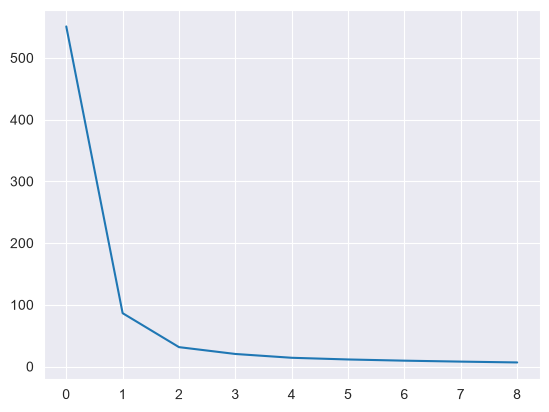

In [73]:
plt.plot(sse)

In [74]:
km = KMeans(n_clusters=3)
km.fit(df[["petal length (cm)","petal width (cm)"]])
y_pred = km.predict(df[["petal length (cm)","petal width (cm)"]])

In [75]:
df["cluster"] = y_pred
km.cluster_centers_

array([[5.62608696, 2.04782609],
       [1.462     , 0.246     ],
       [4.29259259, 1.35925926]])

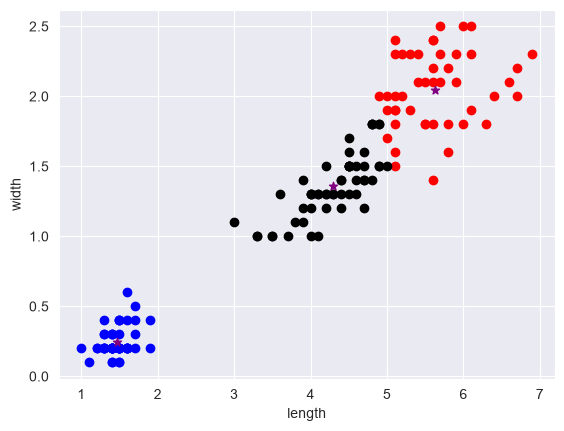

In [76]:
df1 = df[df["cluster"] == 0]
df2 = df[df["cluster"] == 1]
df3 = df[df["cluster"] == 2]
plt.scatter(df1["petal length (cm)"], df1["petal width (cm)"], color="red")
plt.scatter(df2["petal length (cm)"], df2["petal width (cm)"], color="blue")
plt.scatter(df3["petal length (cm)"], df3["petal width (cm)"], color="black")
plt.scatter(km.cluster_centers_[:,0], km.cluster_centers_[:,1], color="purple", marker="*")
plt.xlabel("length")
plt.ylabel("width")
plt.show()